# Analysis of Prompt Engineering Impact on LLM Scaling Laws

This notebook analyzes the results from `experiment_tracking.csv` to understand how different prompt engineering techniques affect the scaling laws of Large Language Models (LLMs). We will focus on visualizing the relationship between model size, accuracy, and the prompting technique used.

## 1. Setup and Data Loading

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Load only the real experiment tracking file
try:
    df = pd.read_csv('../experiment_tracking.csv')
except FileNotFoundError:
    df = pd.read_csv('experiment_tracking.csv')

# Keep analysis focused on fields requested by the user
required_columns = [
    'model_name',
    'model_family',
    'dataset',
    'technique_category',
    'params_billions',
    'accuracy',
]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns in CSV: {missing_columns}")

analysis_df = df[required_columns].copy()

# Numeric cleanup
analysis_df['params_billions'] = pd.to_numeric(analysis_df['params_billions'], errors='coerce')
analysis_df['accuracy'] = pd.to_numeric(analysis_df['accuracy'], errors='coerce')

# Fix legacy rows where accuracy was logged on a 0-1000-like scale (e.g., 475 -> 0.475)
analysis_df.loc[analysis_df['accuracy'] > 1, 'accuracy'] = analysis_df.loc[
    analysis_df['accuracy'] > 1, 'accuracy'
] / 1000.0

analysis_df = analysis_df.dropna(
    subset=['params_billions', 'accuracy', 'model_name', 'model_family', 'dataset', 'technique_category']
)
analysis_df = analysis_df[(analysis_df['params_billions'] > 0) & (analysis_df['accuracy'] > 0)]

available_models = sorted(analysis_df['model_name'].unique().tolist())
available_families = sorted(analysis_df['model_family'].unique().tolist())
available_datasets = sorted(analysis_df['dataset'].unique().tolist())
available_techniques = sorted(analysis_df['technique_category'].unique().tolist())

print(f"Rows used for analysis: {len(analysis_df)}")
print(f"Models present in CSV ({len(available_models)}): {available_models}")
print(f"Model families present in CSV ({len(available_families)}): {available_families}")
print(f"Datasets present in CSV ({len(available_datasets)}): {available_datasets}")
print(f"Technique categories present in CSV ({len(available_techniques)}): {available_techniques}")

display(analysis_df.head())

Rows used for analysis: 101
Models present in CSV (8): ['mistral-7b-instruct', 'qwen2.5-0.5b', 'qwen2.5-1.5b', 'qwen2.5-3b', 'qwen2.5-7b', 'smollm-1.7b', 'smollm-360m', 'tinyllama-test']
Model families present in CSV (4): ['Mistral', 'Qwen2.5', 'SmolLM', 'TinyLlama']
Datasets present in CSV (3): ['arc_challenge', 'mmlu', 'sst2']
Technique categories present in CSV (5): ['cot', 'few_shot', 'few_shot_cot', 'role_expert', 'zero_shot']


,model_name,model_family,dataset,technique_category,params_billions,accuracy
0,smollm-360m,SmolLM,sst2,zero_shot,0.36,0.495
1,smollm-360m,SmolLM,sst2,few_shot,0.36,0.487
2,smollm-360m,SmolLM,sst2,cot,0.36,0.540
3,smollm-360m,SmolLM,sst2,few_shot_cot,0.36,0.492
4,smollm-360m,SmolLM,sst2,role_expert,0.36,0.475


## 2. Exploratory Data Analysis (EDA)

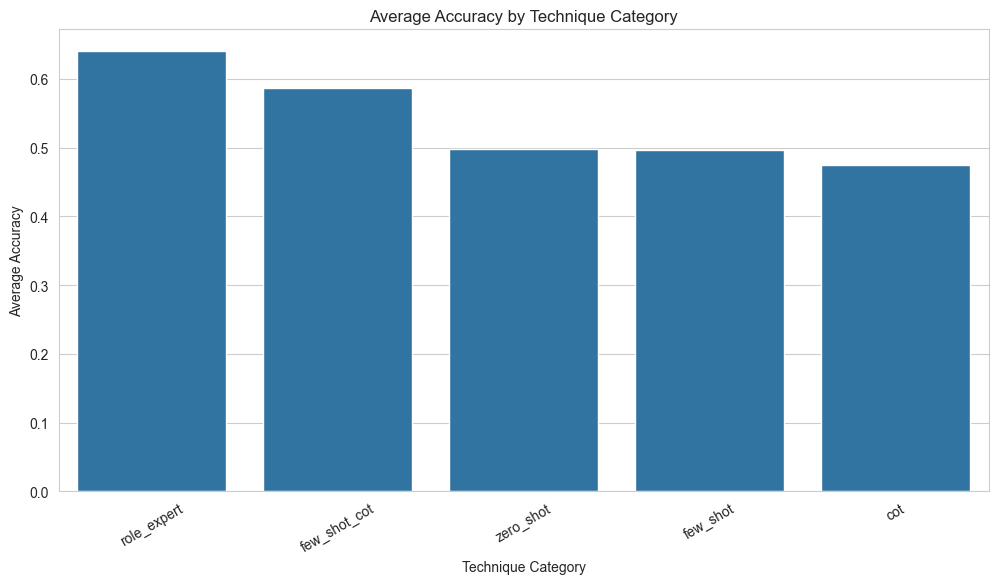

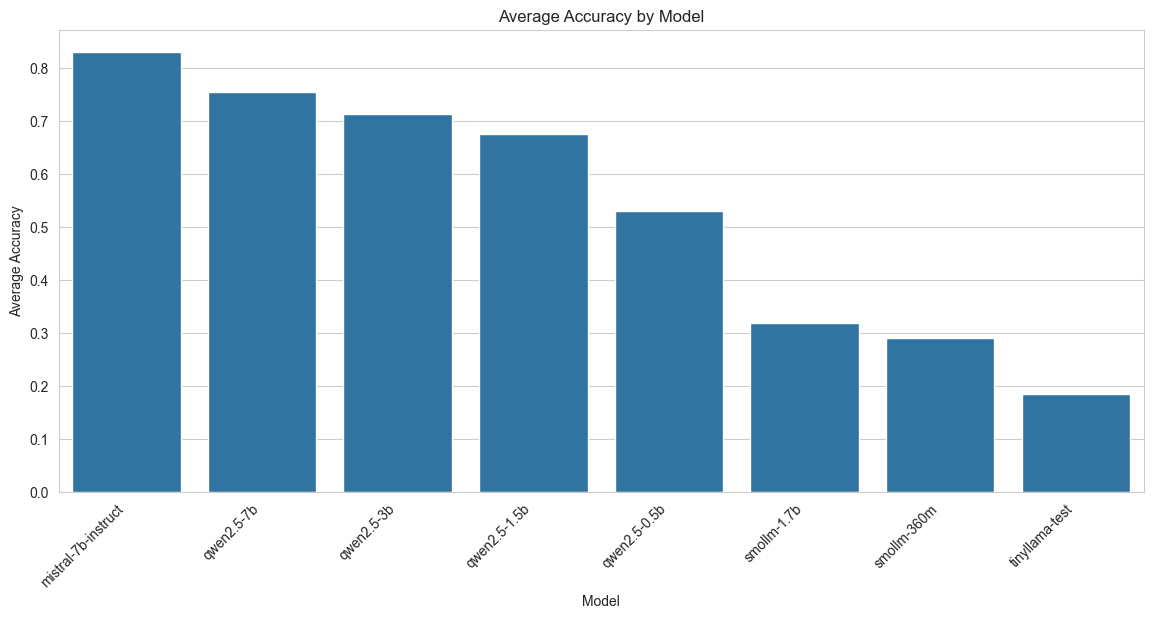

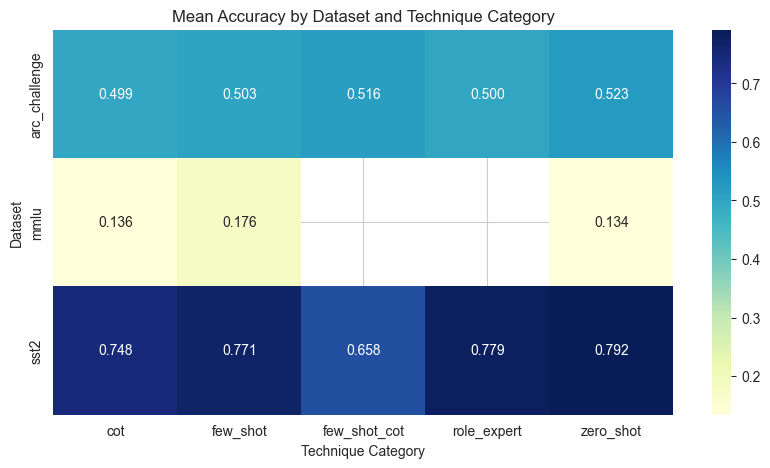

In [8]:
# Set plot style
sns.set_style('whitegrid')

# Average accuracy by technique category (present in CSV)
tech_order = (
    analysis_df.groupby('technique_category')['accuracy']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 6))
sns.barplot(data=analysis_df, x='technique_category', y='accuracy', order=tech_order, errorbar=None)
plt.title('Average Accuracy by Technique Category')
plt.xlabel('Technique Category')
plt.ylabel('Average Accuracy')
plt.xticks(rotation=30)
plt.show()

# Average accuracy by model (present in CSV)
model_order = (
    analysis_df.groupby('model_name')['accuracy']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(14, 6))
sns.barplot(data=analysis_df, x='model_name', y='accuracy', order=model_order, errorbar=None)
plt.title('Average Accuracy by Model')
plt.xlabel('Model')
plt.ylabel('Average Accuracy')
plt.xticks(rotation=45, ha='right')
plt.show()

# Dataset x Technique summary heatmap
dataset_technique_pivot = analysis_df.pivot_table(
    index='dataset',
    columns='technique_category',
    values='accuracy',
    aggfunc='mean',
)

plt.figure(figsize=(10, 5))
sns.heatmap(dataset_technique_pivot, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Mean Accuracy by Dataset and Technique Category')
plt.xlabel('Technique Category')
plt.ylabel('Dataset')
plt.show()

## 3. Scaling Law Analysis by Dataset (Separate Cases)

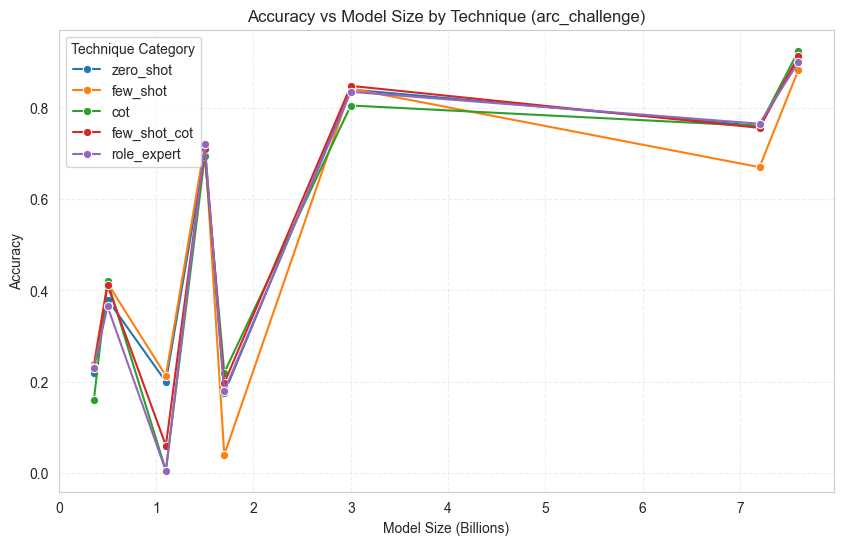

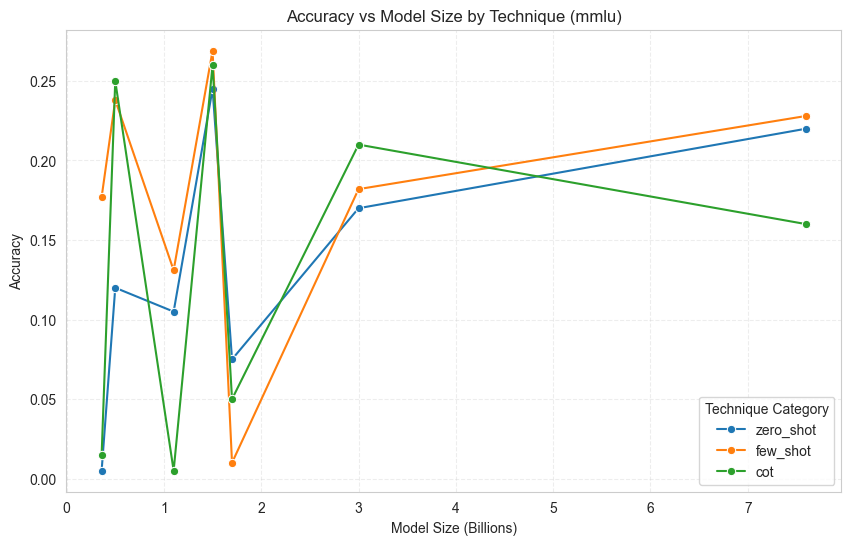

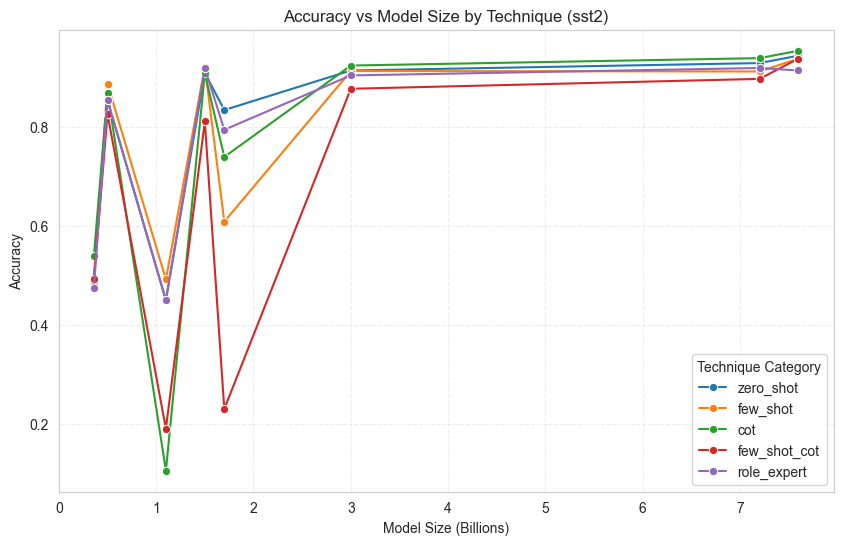

In [20]:
# Separate scaling-law plots for each dataset
for dataset_name in available_datasets:
    dataset_df = analysis_df[analysis_df['dataset'] == dataset_name].copy()
    dataset_df = dataset_df.sort_values('params_billions')

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=dataset_df,
        x='params_billions',
        y='accuracy',
        hue='technique_category',
        marker='o',
        errorbar=None,
    )

    plt.xscale('linear')
    plt.yscale('linear')
    plt.grid(True, which='both', ls='--', alpha=0.35)
    plt.title(f'Accuracy vs Model Size by Technique ({dataset_name})')
    plt.xlabel('Model Size (Billions)')
    plt.ylabel('Accuracy')
    plt.legend(title='Technique Category')
    plt.show()

## 3B. Scaling Law Analysis by Model Family (Qwen Only)

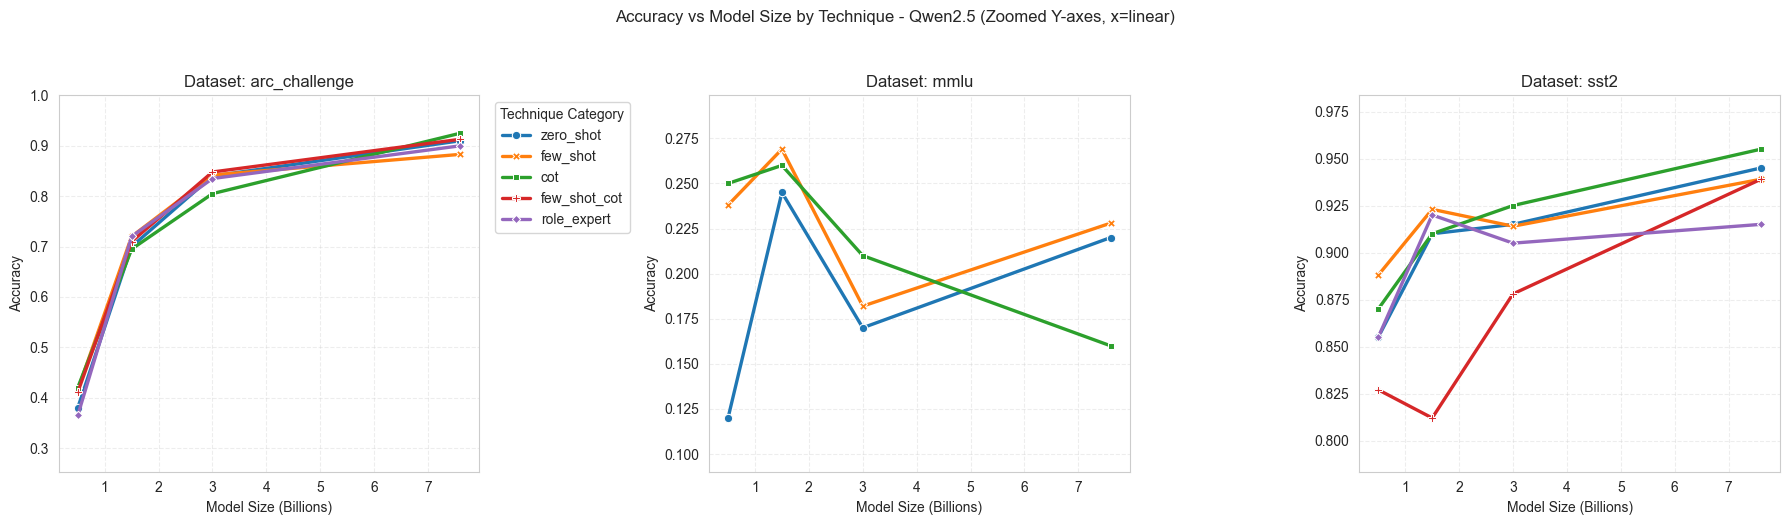

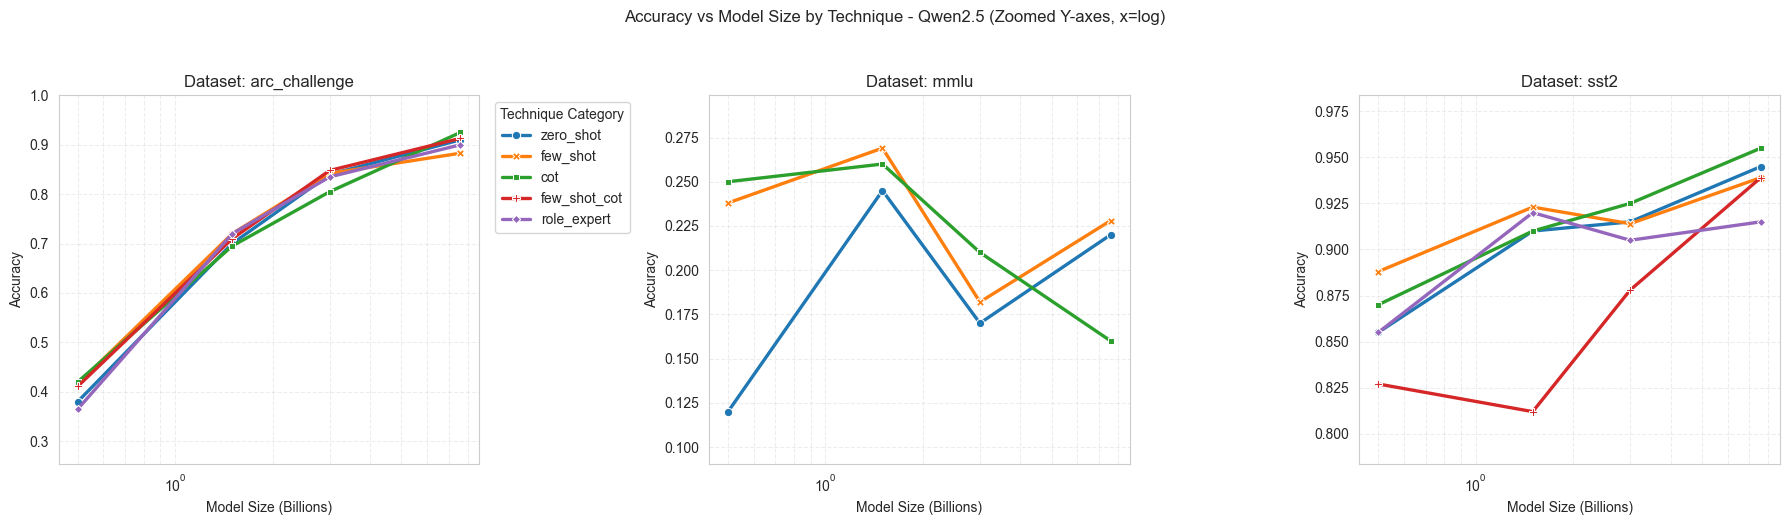

In [32]:
# Copy of scaling-law analysis, restricted to Qwen family only
qwen_families = [fam for fam in available_families if 'qwen' in fam.lower()]
if not qwen_families:
    raise ValueError('No Qwen family found in available_families.')

qwen_family = qwen_families[0]
qwen_df = analysis_df[analysis_df['model_family'] == qwen_family].copy()
qwen_datasets = sorted(qwen_df['dataset'].unique().tolist())


def plot_qwen_family_curves(x_scale, title_suffix):
    fig, axes = plt.subplots(1, len(qwen_datasets), figsize=(6 * len(qwen_datasets), 5), squeeze=False)
    axes = axes[0]

    for i, dataset_name in enumerate(qwen_datasets):
        ax = axes[i]
        dataset_df = qwen_df[qwen_df['dataset'] == dataset_name].copy().sort_values('params_billions')

        sns.lineplot(
            data=dataset_df,
            x='params_billions',
            y='accuracy',
            hue='technique_category',
            style='technique_category',
            markers=True,
            dashes=False,
            linewidth=2.4,
            errorbar=None,
            ax=ax,
            legend=(i == 0),
        )

        # Zoom y-range per dataset to make differences between curves easier to see.
        y_min = dataset_df['accuracy'].min()
        y_max = dataset_df['accuracy'].max()
        y_span = max(y_max - y_min, 0.02)
        y_pad = y_span * 0.20
        ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))

        ax.set_xscale(x_scale)
        ax.set_yscale('linear')
        ax.grid(True, which='both', ls='--', alpha=0.35)
        ax.set_title(f'Dataset: {dataset_name}')
        ax.set_xlabel('Model Size (Billions)')
        ax.set_ylabel('Accuracy')

        if i == 0:
            ax.legend(title='Technique Category', bbox_to_anchor=(1.02, 1), loc='upper left')
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

    fig.suptitle(
        f'Accuracy vs Model Size by Technique - {qwen_family} (Zoomed Y-axes, x={title_suffix})',
        y=1.04,
    )
    fig.tight_layout()
    plt.show()


# Original copy with linear x-axis
plot_qwen_family_curves(x_scale='linear', title_suffix='linear')

# Additional copy requested with log x-axis
plot_qwen_family_curves(x_scale='log', title_suffix='log')

## 3C. Qwen: Best Prompt Technique vs Zero-Shot

Best non-zero-shot technique per dataset for Qwen:


,dataset,best_prompt_technique,best_prompt_mean_accuracy
2,arc_challenge,few_shot_cot,0.72050
5,mmlu,few_shot,0.22925
7,sst2,few_shot,0.91600


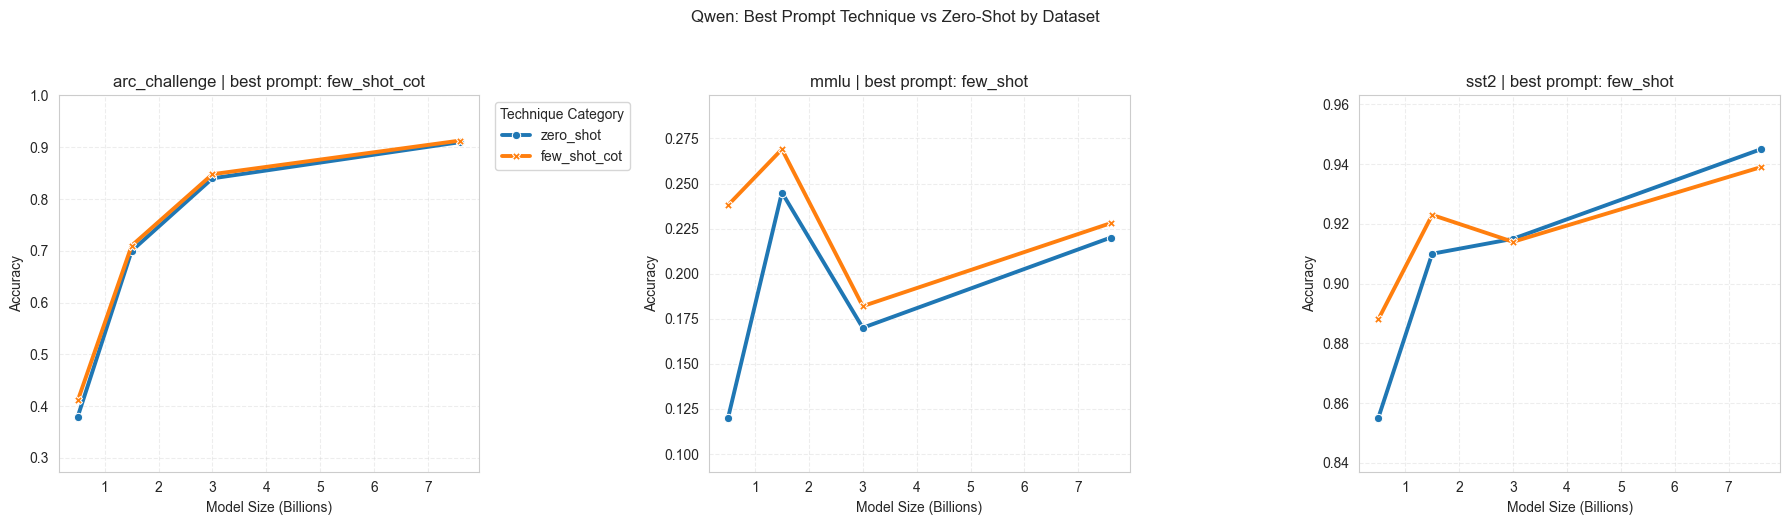

In [28]:
# For each dataset, compare zero-shot vs the best non-zero-shot technique (Qwen only).
qwen_families = [fam for fam in available_families if 'qwen' in fam.lower()]
if not qwen_families:
    raise ValueError('No Qwen family found in available_families.')

qwen_family = qwen_families[0]
qwen_df = analysis_df[analysis_df['model_family'] == qwen_family].copy()

best_prompt_by_dataset = (
    qwen_df[qwen_df['technique_category'] != 'zero_shot']
    .groupby(['dataset', 'technique_category'], as_index=False)['accuracy']
    .mean()
    .sort_values(['dataset', 'accuracy'], ascending=[True, False])
    .drop_duplicates(subset=['dataset'])
    .rename(columns={
        'technique_category': 'best_prompt_technique',
        'accuracy': 'best_prompt_mean_accuracy',
    })
)

print('Best non-zero-shot technique per dataset for Qwen:')
display(best_prompt_by_dataset)

qwen_datasets = sorted(qwen_df['dataset'].unique().tolist())
fig, axes = plt.subplots(1, len(qwen_datasets), figsize=(6 * len(qwen_datasets), 5), squeeze=False)
axes = axes[0]

for i, dataset_name in enumerate(qwen_datasets):
    ax = axes[i]
    dataset_df = qwen_df[qwen_df['dataset'] == dataset_name].copy().sort_values('params_billions')

    best_row = best_prompt_by_dataset[best_prompt_by_dataset['dataset'] == dataset_name]
    keep_techniques = ['zero_shot']
    if not best_row.empty:
        keep_techniques.append(best_row.iloc[0]['best_prompt_technique'])

    plot_df = dataset_df[dataset_df['technique_category'].isin(keep_techniques)].copy()

    sns.lineplot(
        data=plot_df,
        x='params_billions',
        y='accuracy',
        hue='technique_category',
        style='technique_category',
        markers=True,
        dashes=False,
        linewidth=2.8,
        errorbar=None,
        ax=ax,
        legend=(i == 0),
    )

    # Zoom y-range per dataset to make the two-curve comparison clearer.
    y_min = plot_df['accuracy'].min()
    y_max = plot_df['accuracy'].max()
    y_span = max(y_max - y_min, 0.02)
    y_pad = y_span * 0.20
    ax.set_ylim(max(0.0, y_min - y_pad), min(1.0, y_max + y_pad))

    best_name = keep_techniques[1] if len(keep_techniques) > 1 else 'N/A'
    ax.set_title(f'{dataset_name} | best prompt: {best_name}')
    ax.set_xscale('linear')
    ax.set_yscale('linear')
    ax.grid(True, which='both', ls='--', alpha=0.35)
    ax.set_xlabel('Model Size (Billions)')
    ax.set_ylabel('Accuracy')

    if i == 0:
        ax.legend(title='Technique Category', bbox_to_anchor=(1.02, 1), loc='upper left')
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

fig.suptitle(f'Qwen: Best Prompt Technique vs Zero-Shot by Dataset', y=1.04)
fig.tight_layout()
plt.show()

## 4. Estimate Technique Score and Gain Parameters

In [31]:
# Formula-based parameter estimation:
# Score_tech(N) ~= a_tech * log(N) + b_tech
# Delta_tech(N) = Score_tech(N) - Score_base(N)

base_technique = 'zero_shot'

fit_df = analysis_df[(analysis_df['params_billions'] > 0) & (analysis_df['accuracy'] > 0)].copy()
fit_df['log_model_size'] = np.log(fit_df['params_billions'])


def estimate_score_params(input_df, group_keys):
    rows = []

    for key_values, group in input_df.groupby(group_keys):
        if group['params_billions'].nunique() < 2:
            continue

        x = group['log_model_size'].values.reshape(-1, 1)
        y = group['accuracy'].values

        reg = LinearRegression()
        reg.fit(x, y)

        if not isinstance(key_values, tuple):
            key_values = (key_values,)

        row = {k: v for k, v in zip(group_keys, key_values)}
        row.update(
            {
                'a_tech': reg.coef_[0],
                'b_tech': reg.intercept_,
                'r2_score': reg.score(x, y),
                'n_models': group['model_name'].nunique(),
                'n_points': len(group),
            }
        )
        rows.append(row)

    if not rows:
        return pd.DataFrame(columns=group_keys + ['a_tech', 'b_tech', 'r2_score', 'n_models', 'n_points'])

    return pd.DataFrame(rows)


# -----------------------------
# A) Parameters per dataset
# -----------------------------
score_param_df = estimate_score_params(fit_df, ['dataset', 'technique_category'])
score_param_df = score_param_df.sort_values(['dataset', 'a_tech'], ascending=[True, False])

if score_param_df.empty:
    print('No groups had enough model-size variation to estimate a_tech and b_tech (dataset-level).')
else:
    print('Estimated score parameters per dataset and technique:')
    display(score_param_df)

    base_param_df = (
        score_param_df[score_param_df['technique_category'] == base_technique][['dataset', 'a_tech', 'b_tech']]
        .rename(columns={'a_tech': 'a_base', 'b_tech': 'b_base'})
    )

    gain_param_df = score_param_df.merge(base_param_df, on='dataset', how='left')
    gain_param_df = gain_param_df.dropna(subset=['a_base', 'b_base']).copy()
    gain_param_df['delta_a'] = gain_param_df['a_tech'] - gain_param_df['a_base']
    gain_param_df['delta_b'] = gain_param_df['b_tech'] - gain_param_df['b_base']

    print(f'Gain parameters relative to base technique ({base_technique}) at dataset level:')
    display(
        gain_param_df[
            [
                'dataset',
                'technique_category',
                'a_tech',
                'b_tech',
                'a_base',
                'b_base',
                'delta_a',
                'delta_b',
                'r2_score',
                'n_models',
                'n_points',
            ]
        ].sort_values(['dataset', 'delta_a'], ascending=[True, False])
    )

    # Compute observed and parameter-predicted gain at each observed model size.
    base_observed = (
        fit_df[fit_df['technique_category'] == base_technique][
            ['dataset', 'model_name', 'params_billions', 'accuracy']
        ]
        .rename(columns={'accuracy': 'score_base_observed'})
    )

    gain_eval_df = fit_df.merge(
        base_observed,
        on=['dataset', 'model_name', 'params_billions'],
        how='left',
    ).merge(
        gain_param_df[['dataset', 'technique_category', 'delta_a', 'delta_b']],
        on=['dataset', 'technique_category'],
        how='left',
    )

    gain_eval_df['delta_observed'] = gain_eval_df['accuracy'] - gain_eval_df['score_base_observed']
    gain_eval_df['delta_predicted'] = (
        gain_eval_df['delta_a'] * gain_eval_df['log_model_size'] + gain_eval_df['delta_b']
    )

    gain_eval_df = gain_eval_df[gain_eval_df['technique_category'] != base_technique].copy()
    gain_eval_df = gain_eval_df.dropna(subset=['delta_observed', 'delta_predicted'])
    gain_eval_df['abs_error'] = (gain_eval_df['delta_observed'] - gain_eval_df['delta_predicted']).abs()

    gain_fit_quality = (
        gain_eval_df.groupby(['dataset', 'technique_category'], as_index=False)
        .agg(
            mean_observed_gain=('delta_observed', 'mean'),
            mean_predicted_gain=('delta_predicted', 'mean'),
            gain_mae=('abs_error', 'mean'),
            n_points=('delta_observed', 'size'),
        )
        .sort_values(['dataset', 'gain_mae'])
    )

    print('Observed vs predicted gain quality summary (dataset-level):')
    display(gain_fit_quality)


# ---------------------------------------------
# B) Parameters per dataset and model family
# ---------------------------------------------
score_param_family_df = estimate_score_params(fit_df, ['dataset', 'model_family', 'technique_category'])
score_param_family_df = score_param_family_df.sort_values(
    ['dataset', 'model_family', 'a_tech'],
    ascending=[True, True, False],
)

if score_param_family_df.empty:
    print('No groups had enough model-size variation to estimate a_tech and b_tech (family-level).')
else:
    print('Estimated score parameters per dataset, model family, and technique:')
    display(score_param_family_df)

    base_param_family_df = (
        score_param_family_df[
            score_param_family_df['technique_category'] == base_technique
        ][['dataset', 'model_family', 'a_tech', 'b_tech']]
        .rename(columns={'a_tech': 'a_base', 'b_tech': 'b_base'})
    )

    gain_param_family_df = score_param_family_df.merge(
        base_param_family_df,
        on=['dataset', 'model_family'],
        how='left',
    )
    gain_param_family_df = gain_param_family_df.dropna(subset=['a_base', 'b_base']).copy()
    gain_param_family_df['delta_a'] = gain_param_family_df['a_tech'] - gain_param_family_df['a_base']
    gain_param_family_df['delta_b'] = gain_param_family_df['b_tech'] - gain_param_family_df['b_base']

    print(f'Gain parameters relative to base technique ({base_technique}) at model-family level:')
    display(
        gain_param_family_df[
            [
                'dataset',
                'model_family',
                'technique_category',
                'a_tech',
                'b_tech',
                'a_base',
                'b_base',
                'delta_a',
                'delta_b',
                'r2_score',
                'n_models',
                'n_points',
            ]
        ].sort_values(['dataset', 'model_family', 'delta_a'], ascending=[True, True, False])
    )

    base_observed_family = (
        fit_df[fit_df['technique_category'] == base_technique][
            ['dataset', 'model_family', 'model_name', 'params_billions', 'accuracy']
        ]
        .rename(columns={'accuracy': 'score_base_observed'})
    )

    gain_eval_family_df = fit_df.merge(
        base_observed_family,
        on=['dataset', 'model_family', 'model_name', 'params_billions'],
        how='left',
    ).merge(
        gain_param_family_df[
            ['dataset', 'model_family', 'technique_category', 'delta_a', 'delta_b']
        ],
        on=['dataset', 'model_family', 'technique_category'],
        how='left',
    )

    gain_eval_family_df['delta_observed'] = (
        gain_eval_family_df['accuracy'] - gain_eval_family_df['score_base_observed']
    )
    gain_eval_family_df['delta_predicted'] = (
        gain_eval_family_df['delta_a'] * gain_eval_family_df['log_model_size'] + gain_eval_family_df['delta_b']
    )

    gain_eval_family_df = gain_eval_family_df[
        gain_eval_family_df['technique_category'] != base_technique
    ].copy()
    gain_eval_family_df = gain_eval_family_df.dropna(subset=['delta_observed', 'delta_predicted'])
    gain_eval_family_df['abs_error'] = (
        gain_eval_family_df['delta_observed'] - gain_eval_family_df['delta_predicted']
    ).abs()

    gain_fit_quality_family = (
        gain_eval_family_df.groupby(['dataset', 'model_family', 'technique_category'], as_index=False)
        .agg(
            mean_observed_gain=('delta_observed', 'mean'),
            mean_predicted_gain=('delta_predicted', 'mean'),
            gain_mae=('abs_error', 'mean'),
            n_points=('delta_observed', 'size'),
        )
        .sort_values(['dataset', 'model_family', 'gain_mae'])
    )

    print('Observed vs predicted gain quality summary (model-family level):')
    display(gain_fit_quality_family)

Estimated score parameters per dataset and technique:


,dataset,technique_category,a_tech,b_tech,r2_score,n_models,n_points
0,arc_challenge,cot,0.228601,0.372521,0.554934,8,8
3,arc_challenge,role_expert,0.221992,0.377420,0.520338,8,8
2,arc_challenge,few_shot_cot,0.213709,0.397994,0.523594,8,8
4,arc_challenge,zero_shot,0.213016,0.405502,0.588312,8,8
1,arc_challenge,few_shot,0.184942,0.400628,0.421545,8,8
7,mmlu,zero_shot,0.056727,0.114485,0.491930,7,7
5,mmlu,cot,0.025971,0.126649,0.059064,7,7
6,mmlu,few_shot,0.001915,0.175760,0.000528,7,7
10,sst2,few_shot_cot,0.128744,0.587160,0.217621,8,8
8,sst2,cot,0.127989,0.677452,0.235581,8,8


Gain parameters relative to base technique (zero_shot) at dataset level:


,dataset,technique_category,a_tech,b_tech,a_base,b_base,delta_a,delta_b,r2_score,n_models,n_points
0,arc_challenge,cot,0.228601,0.372521,0.213016,0.405502,0.015585,-0.032981,0.554934,8,8
1,arc_challenge,role_expert,0.221992,0.377420,0.213016,0.405502,0.008976,-0.028081,0.520338,8,8
2,arc_challenge,few_shot_cot,0.213709,0.397994,0.213016,0.405502,0.000693,-0.007508,0.523594,8,8
3,arc_challenge,zero_shot,0.213016,0.405502,0.213016,0.405502,0.000000,0.000000,0.588312,8,8
4,arc_challenge,few_shot,0.184942,0.400628,0.213016,0.405502,-0.028074,-0.004873,0.421545,8,8
5,mmlu,zero_shot,0.056727,0.114485,0.056727,0.114485,0.000000,0.000000,0.491930,7,7
6,mmlu,cot,0.025971,0.126649,0.056727,0.114485,-0.030756,0.012164,0.059064,7,7
7,mmlu,few_shot,0.001915,0.175760,0.056727,0.114485,-0.054812,0.061275,0.000528,7,7
8,sst2,few_shot_cot,0.128744,0.587160,0.116044,0.727798,0.012700,-0.140638,0.217621,8,8
9,sst2,cot,0.127989,0.677452,0.116044,0.727798,0.011945,-0.050346,0.235581,8,8


Observed vs predicted gain quality summary (dataset-level):


...

,dataset,model_family,technique_category,a_tech,b_tech,r2_score,n_models,n_points
4,arc_challenge,Qwen2.5,zero_shot,0.197522,0.567305,0.929089,4,4
3,arc_challenge,Qwen2.5,role_expert,0.197479,0.564836,0.902169,4,4
2,arc_challenge,Qwen2.5,few_shot_cot,0.187530,0.587397,0.930989,4,4
0,arc_challenge,Qwen2.5,cot,0.185262,0.579757,0.971384,4,4
1,arc_challenge,Qwen2.5,few_shot,0.174381,0.591480,0.897880,4,4
5,arc_challenge,SmolLM,cot,0.038653,0.199490,1.000000,2,2
7,arc_challenge,SmolLM,few_shot_cot,-0.023192,0.209306,1.000000,2,2
9,arc_challenge,SmolLM,zero_shot,-0.028990,0.190383,1.000000,2,2
8,arc_challenge,SmolLM,role_expert,-0.032211,0.197092,1.000000,2,2
6,arc_challenge,SmolLM,few_shot,-0.127554,0.107684,1.000000,2,2


Gain parameters relative to base technique (zero_shot) at model-family level:


,dataset,model_family,technique_category,a_tech,b_tech,a_base,b_base,delta_a,delta_b,r2_score,n_models,n_points
0,arc_challenge,Qwen2.5,zero_shot,0.197522,0.567305,0.197522,0.567305,0.000000,0.000000,0.929089,4,4
1,arc_challenge,Qwen2.5,role_expert,0.197479,0.564836,0.197522,0.567305,-0.000043,-0.002469,0.902169,4,4
2,arc_challenge,Qwen2.5,few_shot_cot,0.187530,0.587397,0.197522,0.567305,-0.009992,0.020092,0.930989,4,4
3,arc_challenge,Qwen2.5,cot,0.185262,0.579757,0.197522,0.567305,-0.012260,0.012452,0.971384,4,4
4,arc_challenge,Qwen2.5,few_shot,0.174381,0.591480,0.197522,0.567305,-0.023141,0.024175,0.897880,4,4
5,arc_challenge,SmolLM,cot,0.038653,0.199490,-0.028990,0.190383,0.067642,0.009107,1.000000,2,2
6,arc_challenge,SmolLM,few_shot_cot,-0.023192,0.209306,-0.028990,0.190383,0.005798,0.018923,1.000000,2,2
7,arc_challenge,SmolLM,zero_shot,-0.028990,0.190383,-0.028990,0.190383,0.000000,0.000000,1.000000,2,2
8,arc_challenge,SmolLM,role_expert,-0.032211,0.197092,-0.028990,0.190383,-0.003221,0.006709,1.000000,2,2
9,arc_challenge,SmolLM,few_shot,-0.127554,0.107684,-0.028990,0.190383,-0.098565,-0.082699,1.000000,2,2


Observed vs predicted gain quality summary (model-family level):


,dataset,model_family,technique_category,mean_observed_gain,mean_predicted_gain,gain_mae,n_points
2,arc_challenge,Qwen2.5,few_shot_cot,0.01300,0.01300,3.577666e-03,4
1,arc_challenge,Qwen2.5,few_shot,0.00775,0.00775,4.228153e-03,4
3,arc_challenge,Qwen2.5,role_expert,-0.00250,-0.00250,1.124344e-02,4
0,arc_challenge,Qwen2.5,cot,0.00375,0.00375,2.323177e-02,4
7,arc_challenge,SmolLM,role_expert,0.00750,0.00750,4.336809e-18,2
6,arc_challenge,SmolLM,few_shot_cot,0.01750,0.01750,1.040834e-17,2
5,arc_challenge,SmolLM,few_shot,-0.05850,-0.05850,2.081668e-17,2
4,arc_challenge,SmolLM,cot,-0.00750,-0.00750,2.775558e-17,2
9,mmlu,Qwen2.5,few_shot,0.04050,0.04050,2.081319e-02,4
8,mmlu,Qwen2.5,cot,0.03125,0.03125,2.159659e-02,4


## 5. Ranked Summary Tables by Dataset

In [17]:
# Mean accuracy rankings within each dataset
technique_rank = (
    analysis_df.groupby(['dataset', 'technique_category'], as_index=False)['accuracy']
    .mean()
    .rename(columns={'accuracy': 'mean_accuracy'})
)
technique_rank['technique_rank'] = technique_rank.groupby('dataset')['mean_accuracy'].rank(
    method='dense', ascending=False
).astype(int)
technique_rank = technique_rank.sort_values(['dataset', 'technique_rank', 'technique_category'])

model_rank = (
    analysis_df.groupby(['dataset', 'model_name'], as_index=False)['accuracy']
    .mean()
    .rename(columns={'accuracy': 'mean_accuracy'})
)
model_rank['model_rank'] = model_rank.groupby('dataset')['mean_accuracy'].rank(
    method='dense', ascending=False
).astype(int)
model_rank = model_rank.sort_values(['dataset', 'model_rank', 'model_name'])

# Top-1 summary per dataset
best_technique = (
    technique_rank[technique_rank['technique_rank'] == 1]
    .sort_values(['dataset', 'technique_category'])
    .drop_duplicates(subset=['dataset'])
    [['dataset', 'technique_category', 'mean_accuracy']]
    .rename(columns={
        'technique_category': 'best_technique_category',
        'mean_accuracy': 'best_technique_mean_accuracy',
    })
)

best_model = (
    model_rank[model_rank['model_rank'] == 1]
    .sort_values(['dataset', 'model_name'])
    .drop_duplicates(subset=['dataset'])
    [['dataset', 'model_name', 'mean_accuracy']]
    .rename(columns={
        'model_name': 'best_model_name',
        'mean_accuracy': 'best_model_mean_accuracy',
    })
)

final_ranked_summary = (
    best_technique.merge(best_model, on='dataset', how='inner')
    .sort_values('dataset')
    .reset_index(drop=True)
)

print('Final ranked summary per dataset (best technique category and best model):')
display(final_ranked_summary)

print('Detailed technique rankings within each dataset:')
display(technique_rank)

print('Detailed model rankings within each dataset:')
display(model_rank)

Final ranked summary per dataset (best technique category and best model):


,dataset,best_technique_category,best_technique_mean_accuracy,best_model_name,best_model_mean_accuracy
0,arc_challenge,zero_shot,0.523125,qwen2.5-7b,0.9062
1,mmlu,few_shot,0.176429,qwen2.5-1.5b,0.2580
2,sst2,zero_shot,0.791875,qwen2.5-7b,0.9386


Detailed technique rankings within each dataset:


,dataset,technique_category,mean_accuracy,technique_rank
4,arc_challenge,zero_shot,0.523125,1
2,arc_challenge,few_shot_cot,0.516000,2
1,arc_challenge,few_shot,0.502750,3
3,arc_challenge,role_expert,0.500000,4
0,arc_challenge,cot,0.498750,5
6,mmlu,few_shot,0.176429,1
5,mmlu,cot,0.135714,2
7,mmlu,zero_shot,0.134286,3
12,sst2,zero_shot,0.791875,1
11,sst2,role_expert,0.779375,2


Detailed model rankings within each dataset:


,dataset,model_name,mean_accuracy,model_rank
4,arc_challenge,qwen2.5-7b,0.906200,1
3,arc_challenge,qwen2.5-3b,0.834000,2
0,arc_challenge,mistral-7b-instruct,0.742200,3
2,arc_challenge,qwen2.5-1.5b,0.709000,4
1,arc_challenge,qwen2.5-0.5b,0.398400,5
6,arc_challenge,smollm-360m,0.216200,6
5,arc_challenge,smollm-1.7b,0.162400,7
7,arc_challenge,tinyllama-test,0.096600,8
9,mmlu,qwen2.5-1.5b,0.258000,1
8,mmlu,qwen2.5-0.5b,0.202667,2


## 6. Model Family Comparison

Prompt gain summary by dataset and model family:


,dataset,model_family,avg_zero_shot_accuracy,avg_best_prompt_accuracy,avg_prompt_gain,n_models
2,arc_challenge,SmolLM,0.19750,0.22900,0.03150,2
1,arc_challenge,Qwen2.5,0.70750,0.72825,0.02075,4
3,arc_challenge,TinyLlama,0.20000,0.21300,0.01300,1
0,arc_challenge,Mistral,0.76000,0.76500,0.00500,1
5,mmlu,SmolLM,0.04000,0.12600,0.08600,2
4,mmlu,Qwen2.5,0.18875,0.23925,0.05050,4
6,mmlu,TinyLlama,0.10500,0.13100,0.02600,1
10,sst2,TinyLlama,0.45000,0.49200,0.04200,1
9,sst2,SmolLM,0.66500,0.68750,0.02250,2
8,sst2,Qwen2.5,0.90625,0.92275,0.01650,4


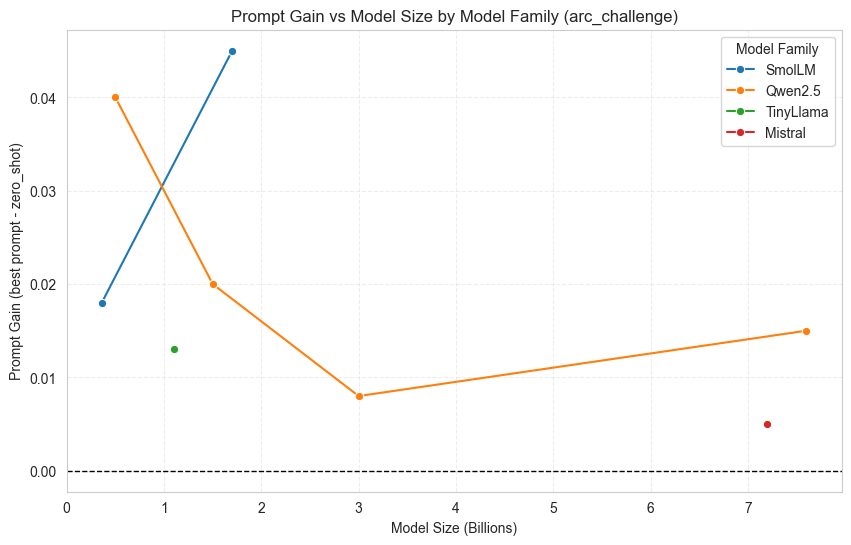

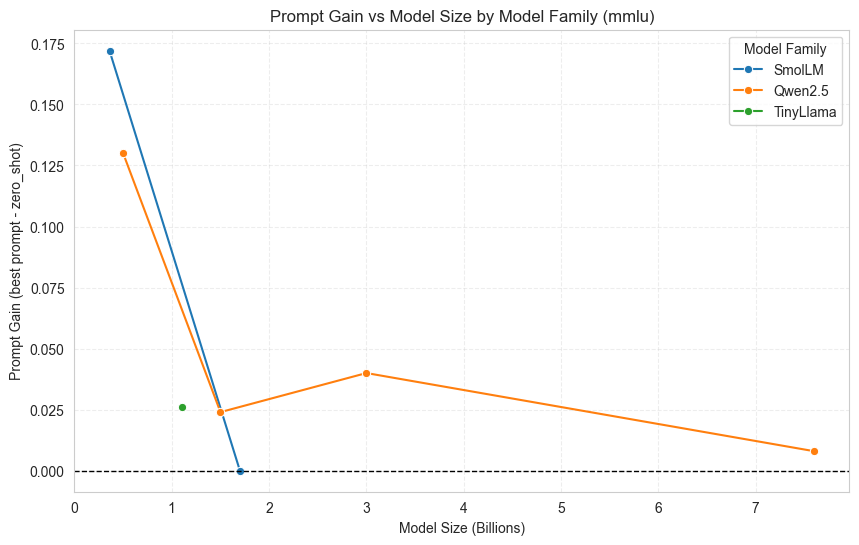

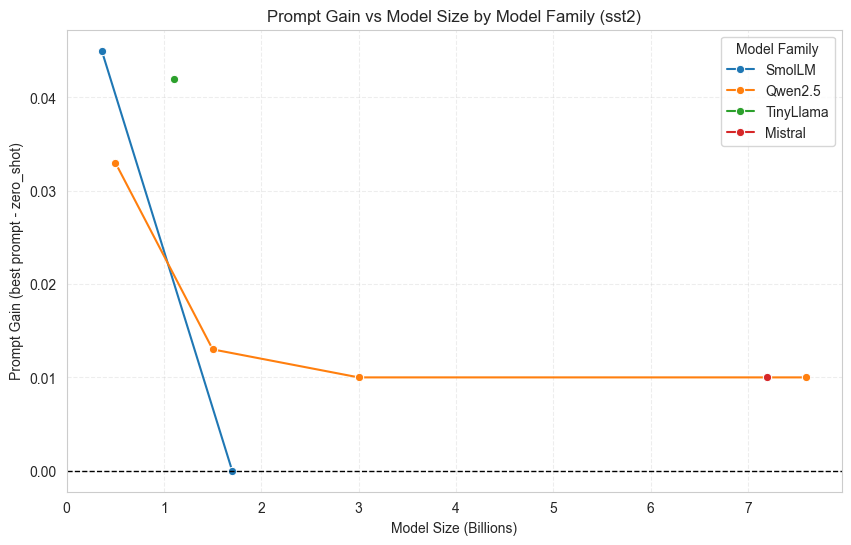

In [21]:
# Compare prompt-engineering gains between model families
# Gain is measured as (best prompt accuracy - zero_shot accuracy) for each (dataset, model).
family_key = ['dataset', 'model_name', 'model_family', 'params_billions']

zero_shot_df = (
    analysis_df[analysis_df['technique_category'] == 'zero_shot'][family_key + ['accuracy']]
    .rename(columns={'accuracy': 'zero_shot_accuracy'})
)

best_prompt_df = (
    analysis_df.groupby(family_key, as_index=False)['accuracy']
    .max()
    .rename(columns={'accuracy': 'best_prompt_accuracy'})
)

family_gain_df = best_prompt_df.merge(zero_shot_df, on=family_key, how='left')
family_gain_df = family_gain_df.dropna(subset=['zero_shot_accuracy'])
family_gain_df['prompt_gain'] = family_gain_df['best_prompt_accuracy'] - family_gain_df['zero_shot_accuracy']

family_gain_summary = (
    family_gain_df.groupby(['dataset', 'model_family'], as_index=False)
    .agg(
        avg_zero_shot_accuracy=('zero_shot_accuracy', 'mean'),
        avg_best_prompt_accuracy=('best_prompt_accuracy', 'mean'),
        avg_prompt_gain=('prompt_gain', 'mean'),
        n_models=('model_name', 'nunique'),
    )
    .sort_values(['dataset', 'avg_prompt_gain'], ascending=[True, False])
)

print('Prompt gain summary by dataset and model family:')
display(family_gain_summary)

# Plot family-wise gain vs model size for each dataset
for dataset_name in available_datasets:
    dataset_family_gain = family_gain_df[family_gain_df['dataset'] == dataset_name].copy()
    if dataset_family_gain.empty:
        continue

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=dataset_family_gain.sort_values('params_billions'),
        x='params_billions',
        y='prompt_gain',
        hue='model_family',
        marker='o',
        errorbar=None,
    )
    plt.xscale('linear')
    plt.axhline(0.0, color='black', linewidth=1, linestyle='--')
    plt.grid(True, which='both', ls='--', alpha=0.35)
    plt.title(f'Prompt Gain vs Model Size by Model Family ({dataset_name})')
    plt.xlabel('Model Size (Billions)')
    plt.ylabel('Prompt Gain (best prompt - zero_shot)')
    plt.legend(title='Model Family')
    plt.show()

## 7. Beneficial Trends and Patterns

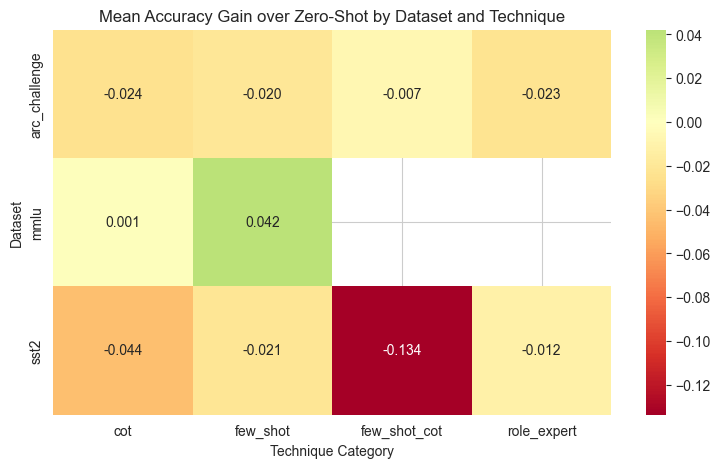

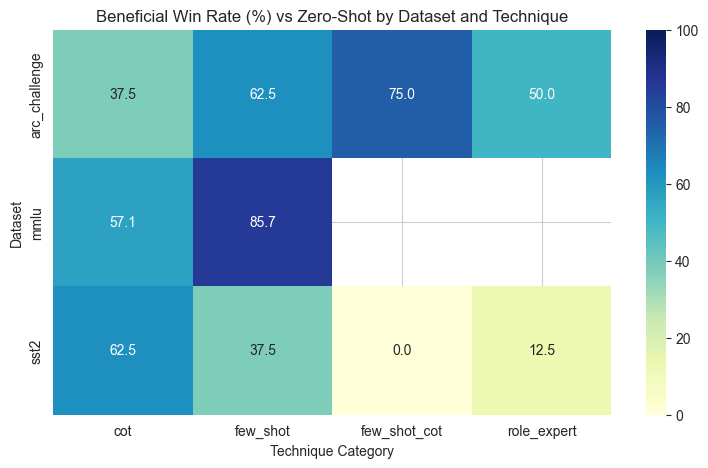

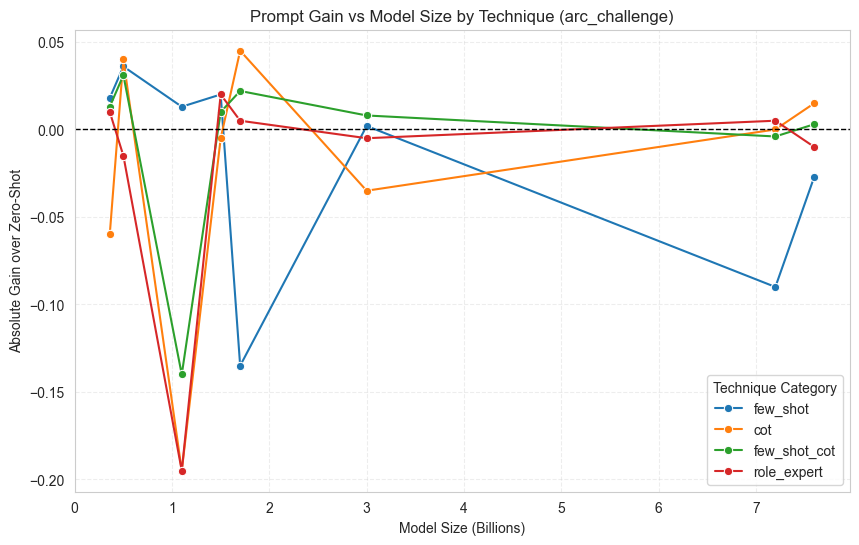

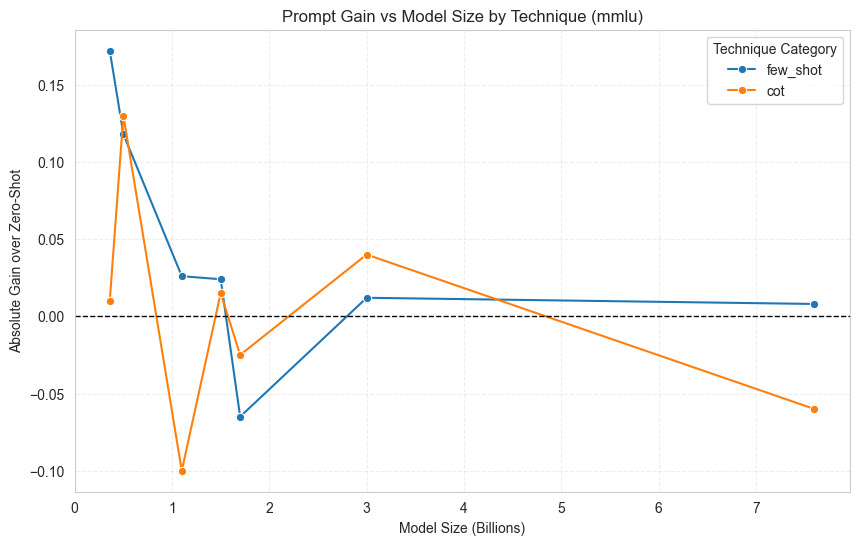

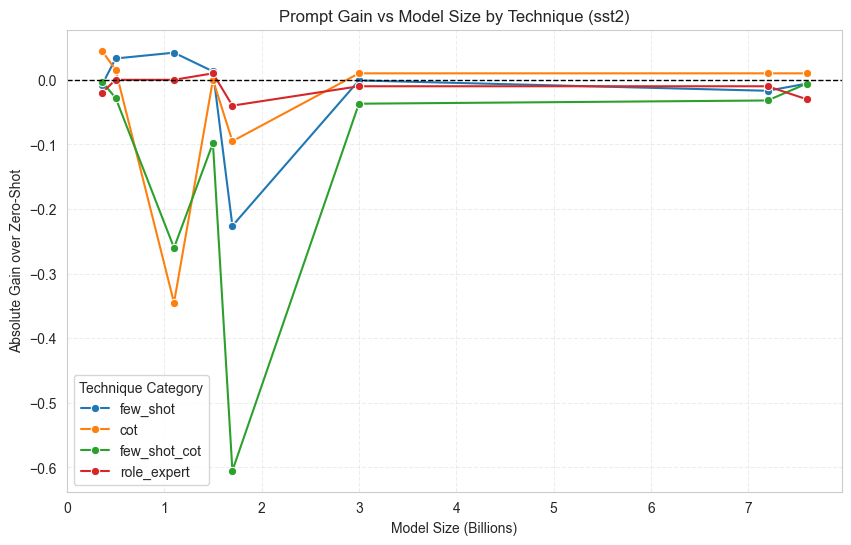

Trend summary by dataset and technique category (vs zero-shot):


,dataset,technique_category,mean_abs_gain,median_abs_gain,max_abs_gain,win_rate_pct,n_models
2,arc_challenge,few_shot_cot,-0.007125,0.0090,0.031,75.000000,8
1,arc_challenge,few_shot,-0.020375,0.0075,0.036,62.500000,8
3,arc_challenge,role_expert,-0.023125,0.0000,0.020,50.000000,8
0,arc_challenge,cot,-0.024375,-0.0025,0.045,37.500000,8
5,mmlu,few_shot,0.042143,0.0240,0.172,85.714286,7
4,mmlu,cot,0.001429,0.0100,0.130,57.142857,7
9,sst2,role_expert,-0.012500,-0.0100,0.010,12.500000,8
7,sst2,few_shot,-0.021250,-0.0035,0.042,37.500000,8
6,sst2,cot,-0.043750,0.0100,0.045,62.500000,8
8,sst2,few_shot_cot,-0.133625,-0.0345,-0.003,0.000000,8


Most beneficial positive-mean technique pattern per dataset:


,dataset,technique_category,mean_abs_gain,median_abs_gain,max_abs_gain,win_rate_pct,n_models
0,mmlu,few_shot,0.042143,0.024,0.172,85.714286,7


Datasets with no net-positive mean gain technique vs zero-shot:
['arc_challenge', 'sst2']


In [23]:
# Build per-technique gain vs zero-shot for trend finding
baseline_cols = ['dataset', 'model_name', 'params_billions', 'accuracy']
zero_baseline = (
    analysis_df[analysis_df['technique_category'] == 'zero_shot'][baseline_cols]
    .rename(columns={'accuracy': 'zero_shot_accuracy'})
)

tech_gain_df = analysis_df.merge(
    zero_baseline,
    on=['dataset', 'model_name', 'params_billions'],
    how='left',
)
tech_gain_df = tech_gain_df.dropna(subset=['zero_shot_accuracy'])
tech_gain_df['abs_gain'] = tech_gain_df['accuracy'] - tech_gain_df['zero_shot_accuracy']
tech_gain_df['pct_gain'] = np.where(
    tech_gain_df['zero_shot_accuracy'] > 0,
    100.0 * tech_gain_df['abs_gain'] / tech_gain_df['zero_shot_accuracy'],
    np.nan,
)

non_zero_tech_gain_df = tech_gain_df[tech_gain_df['technique_category'] != 'zero_shot'].copy()

# 1) Mean absolute gain heatmap (benefit intensity)
mean_gain_heatmap = non_zero_tech_gain_df.pivot_table(
    index='dataset',
    columns='technique_category',
    values='abs_gain',
    aggfunc='mean',
)

plt.figure(figsize=(9, 5))
sns.heatmap(mean_gain_heatmap, annot=True, fmt='.3f', center=0, cmap='RdYlGn')
plt.title('Mean Accuracy Gain over Zero-Shot by Dataset and Technique')
plt.xlabel('Technique Category')
plt.ylabel('Dataset')
plt.show()

# 2) Win-rate heatmap: fraction of models where technique beats zero-shot
win_rate_table = (
    non_zero_tech_gain_df.assign(is_beneficial=non_zero_tech_gain_df['abs_gain'] > 0)
    .groupby(['dataset', 'technique_category'])['is_beneficial']
    .mean()
    .mul(100)
    .unstack('technique_category')
)

plt.figure(figsize=(9, 5))
sns.heatmap(win_rate_table, annot=True, fmt='.1f', vmin=0, vmax=100, cmap='YlGnBu')
plt.title('Beneficial Win Rate (%) vs Zero-Shot by Dataset and Technique')
plt.xlabel('Technique Category')
plt.ylabel('Dataset')
plt.show()

# 3) Gain vs model size trend per dataset (linear model-size axis)
for dataset_name in available_datasets:
    plot_gain = non_zero_tech_gain_df[non_zero_tech_gain_df['dataset'] == dataset_name].copy()
    if plot_gain.empty:
        continue

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=plot_gain.sort_values('params_billions'),
        x='params_billions',
        y='abs_gain',
        hue='technique_category',
        marker='o',
        errorbar=None,
    )
    plt.xscale('linear')
    plt.axhline(0.0, color='black', linewidth=1, linestyle='--')
    plt.grid(True, which='both', ls='--', alpha=0.35)
    plt.title(f'Prompt Gain vs Model Size by Technique ({dataset_name})')
    plt.xlabel('Model Size (Billions)')
    plt.ylabel('Absolute Gain over Zero-Shot')
    plt.legend(title='Technique Category')
    plt.show()

# Trend summary table for findings
trend_summary = (
    non_zero_tech_gain_df.groupby(['dataset', 'technique_category'], as_index=False)
    .agg(
        mean_abs_gain=('abs_gain', 'mean'),
        median_abs_gain=('abs_gain', 'median'),
        max_abs_gain=('abs_gain', 'max'),
        win_rate_pct=('abs_gain', lambda s: 100.0 * (s > 0).mean()),
        n_models=('model_name', 'nunique'),
    )
    .sort_values(['dataset', 'mean_abs_gain'], ascending=[True, False])
)

positive_trend_summary = trend_summary[trend_summary['mean_abs_gain'] > 0].copy()

if positive_trend_summary.empty:
    best_positive_trend_per_dataset = pd.DataFrame(
        columns=trend_summary.columns
    )
else:
    best_positive_trend_per_dataset = (
        positive_trend_summary.sort_values(
            ['dataset', 'mean_abs_gain', 'win_rate_pct'],
            ascending=[True, False, False],
        )
        .drop_duplicates(subset=['dataset'])
        .reset_index(drop=True)
    )

datasets_without_positive_mean_gain = sorted(
    set(available_datasets) - set(best_positive_trend_per_dataset['dataset'].tolist())
)

print('Trend summary by dataset and technique category (vs zero-shot):')
display(trend_summary)

print('Most beneficial positive-mean technique pattern per dataset:')
display(best_positive_trend_per_dataset)

if datasets_without_positive_mean_gain:
    print('Datasets with no net-positive mean gain technique vs zero-shot:')
    print(datasets_without_positive_mean_gain)

## 8. Summary of Findings

This notebook analyzes prompt-engineering effects on accuracy vs model size using only values present in `experiment_tracking.csv` and these fields:

1. `technique_category`
2. `model_name`
3. `model_family`
4. `dataset`

What this notebook provides:

1. Separate dataset-specific scaling plots for accuracy vs model size, with linear model-size axis in all graphs.
2. Per-dataset scaling-fit tables (`slope_alpha`) to quantify how each technique changes with size.
3. Ranked summaries of strongest technique category and strongest model per dataset.
4. Model-family comparison using prompt gain (`best prompt - zero_shot`) vs model size.
5. Beneficial-pattern analysis versus zero-shot:
   - mean gain heatmap,
   - beneficial win-rate heatmap,
   - gain-vs-size trend lines by technique,
   - a final table of most beneficial positive-mean technique patterns.

Key findings from the current results:

1. `mmlu` is the only dataset with clear net-positive prompt gains on average:
   - `few_shot` has the strongest mean gain (+0.042) with high win rate (85.7%).
2. `arc_challenge` shows mixed behavior:
   - techniques can win on many individual models (e.g., `few_shot_cot` win rate 75%),
   - but all techniques are net-negative on mean gain vs `zero_shot`, indicating occasional large regressions.
3. `sst2` is prompt-sensitive but mostly negative relative to `zero_shot` on average:
   - `few_shot_cot` is consistently harmful (mean gain -0.134, win rate 0%).
4. Model-family trend:
   - smaller families (especially `SmolLM` on `mmlu`) show larger average prompt gains,
   - larger strong baselines (e.g., `Mistral`, larger `Qwen2.5`) tend to show smaller incremental gains.

Overall, prompt engineering appears most beneficial for harder reasoning tasks and weaker baselines, while high-performing settings often gain little or may regress depending on technique choice.